# Introduction

## Undirected Graph
The edges between any two vertices in an “undirected graph” do not have a direction, indicating a two-way relationship.
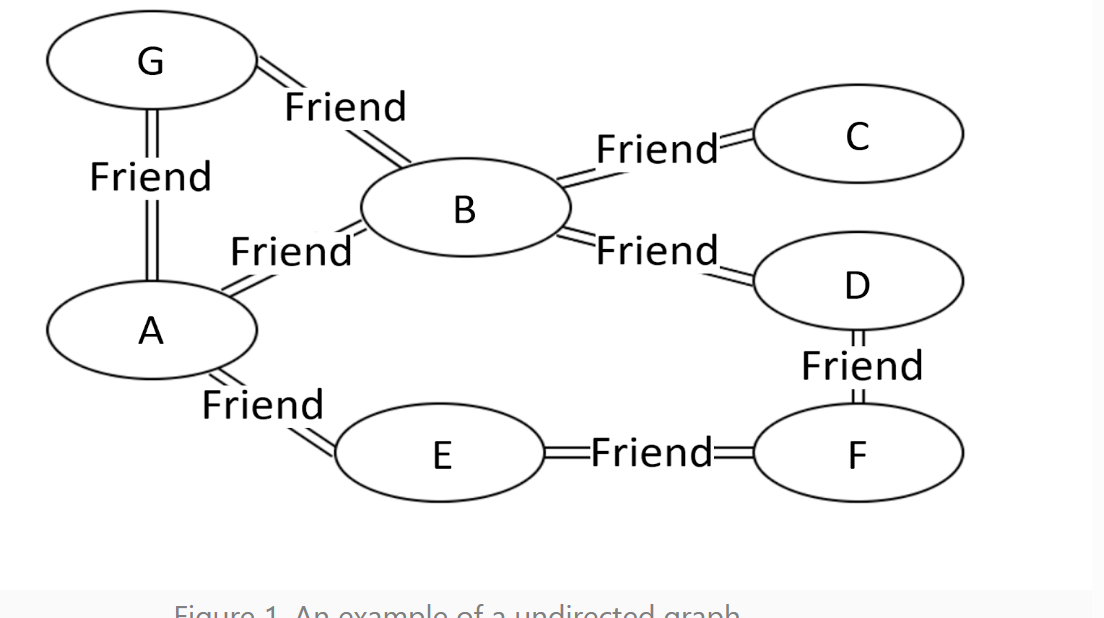

## Directed Graph
The edges between any two vertices in a “directed graph” graph are directional.
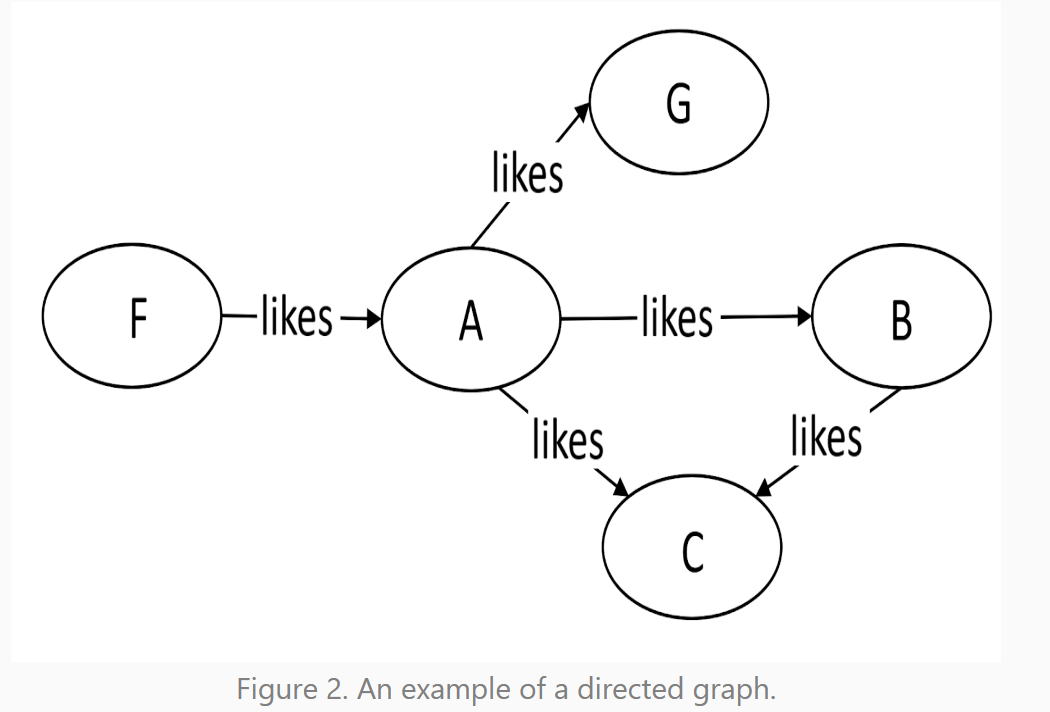

## Weighted Graph
Each edge in a “weighted graph” has an associated weight. The weight can be of any metric, such as time, distance, size, etc. 
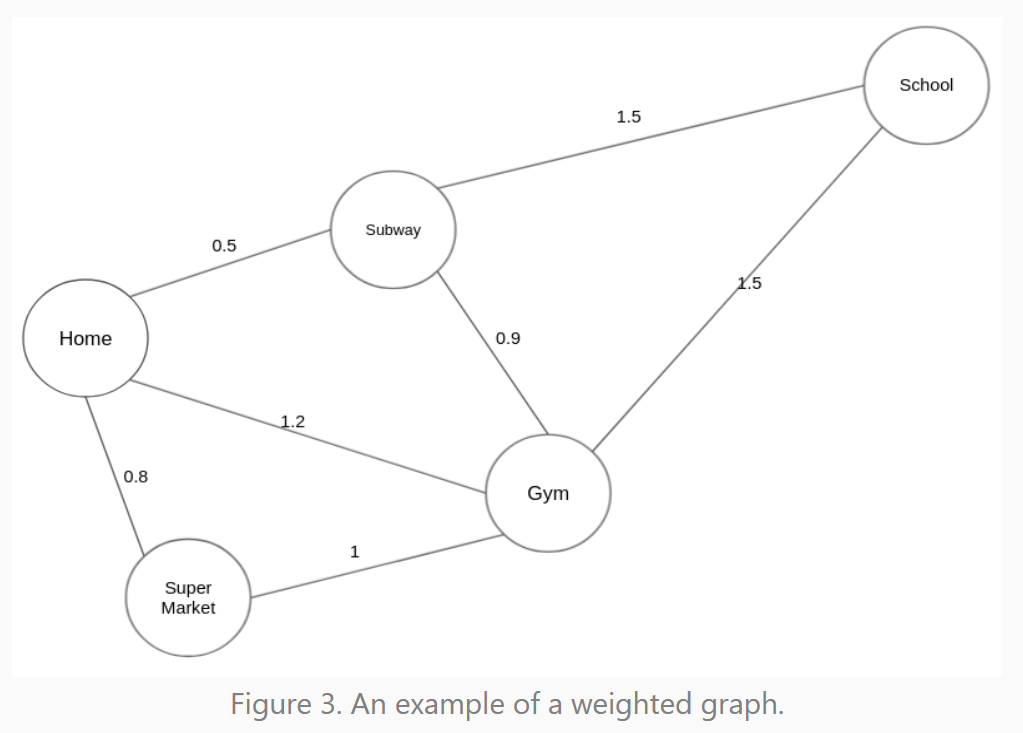

# Disjoint Set
A disjoint set is a data structure that keeps track of a set of elements partitioned into a number of non-overlapping subsets. It provides two primary operations: `find` and `union`:

- The `find` operation determines which subset a particular element is in
- while the `union` operation merges two subsets into a single subset. 

Disjoint sets are commonly used in algorithms that involve grouping or clustering, such as Kruskal's algorithm for finding the minimum spanning tree of a graph.

In [6]:
# Quick find
# store the root node
# Time Complexity
# Find: O(1) | Union: O(N)
# Space complexity
# O(N)
class UnionFind:
    def __init__(self, size) -> None:
        self.root = [i for i in range(size)]

    def find(self, x):
        return self.root[x]

    def union(self, x, y):
        rootX = self.find(x)
        rootY = self.find(y)

        if rootX != rootY:
            for i in range(len(self.root)):
                if self.root[i] == rootY:
                    self.root[i] = rootX

    def connected(self, x, y):
        return self.find(x) == self.find(y)

# Test Case
uf = UnionFind(10)
# 1-2-5-6-7 3-8-9 4
graph = [(1,2), (2,5), (5,6), (6,7), (3,8), (8,9)]

for (x,y) in graph:
    uf.union(x,y)

print(uf.connected(1,5))
print(uf.connected(5,7))
print(uf.connected(4,9))

uf.union(9,4)
print(uf.connected(4,9))


True
True
False
True


In [7]:
# Quick union
# store the parent node
# Time Complexity
# Find: O(N) | Union: O(N)
# Space complexity
# O(N)
class UnionFind:
    def __init__(self, size) -> None:
        self.root = [i for i in range(size)]

    def find(self, x):
        while self.root[x] != x:
            x = self.root[x]
        return x

    def union(self, x, y):
        rootX = self.find(x)
        rootY = self.find(y)
        if rootX != rootY:
            self.root[rootY] = rootX

    def connected(self, x, y):
        return self.find(x) == self.find(y)

# Test Case
uf = UnionFind(10)
# 1-2-5-6-7 3-8-9 4
graph = [(1,2), (2,5), (5,6), (6,7), (3,8), (8,9)]

for (x,y) in graph:
    uf.union(x,y)

print(uf.connected(1,5))
print(uf.connected(5,7))
print(uf.connected(4,9))

uf.union(9,4)
print(uf.connected(4,9))

True
True
False
True


In [9]:
# Union by rank
# store the parent node
# Time Complexity
# Find: O(logN) | Union: O(log N) | connected: O(log N)
# Space complexity
# O(N)
class UnionFind:
    def __init__(self, size) -> None:
        self.root = [i for i in range(size)]
        self.rank = [1] * size

    def find(self, x):
        while self.root[x] != x:
            x = self.root[x]
        return x

    def union(self, x, y):
        rootX = self.find(x)
        rootY = self.find(y)
        if rootX != rootY:
            if self.rank[rootX] < self.rank[rootY]:
                self.root[rootX] = rootY
            elif self.rank[rootX] > self.rank[rootY]: 
                self.root[rootY] = rootX
            else:
                self.root[rootY] = rootX
                self.rank[rootY] += 1

    def connected(self, x, y):
        return self.find(x) == self.find(y)

# Test Case
uf = UnionFind(10)
# 1-2-5-6-7 3-8-9 4
graph = [(1,2), (2,5), (5,6), (6,7), (3,8), (8,9)]

for (x,y) in graph:
    uf.union(x,y)

print(uf.connected(1,5))
print(uf.connected(5,7))
print(uf.connected(4,9))

uf.union(9,4)
print(uf.connected(4,9))

True
True
False
True


In [13]:
# Path compression
# Quick union
# store the parent node
# Time Complexity
# Find: O(N) | Union: O(N)
# Space complexity
# O(N)
class UnionFind:
    def __init__(self, size) -> None:
        self.root = [i for i in range(size)]
        self.rank = [1] * size

    def find(self, x):
        if self.root[x] == x:
            return x
        self.root[x] = self.find(self.root[x])
        return self.root[x]
    
    def union(self, x, y):
        rootX = self.find(x)
        rootY = self.find(y)
        if rootX != rootY:
            if self.rank[rootX] < self.rank[rootY]:
                self.root[rootX] = rootY
            elif self.rank[rootX] > self.rank[rootY]: 
                self.root[rootY] = rootX
            else:
                self.root[rootY] = rootX
                self.rank[rootY] += 1
        
        return 

    def connected(self, x, y):
        return self.find(x) == self.find(y)

# Test Case
uf = UnionFind(10)
# 1-2-5-6-7 3-8-9 4
graph = [(1,2), (2,5), (5,6), (6,7), (3,8), (8,9)]

for (x,y) in graph:
    uf.union(x,y)

print(uf.connected(1,5))
print(uf.connected(5,7))
print(uf.connected(4,9))

uf.union(9,4)
print(uf.connected(4,9))
print([uf.find(i) for i in range(10)])

True
True
False
True
[0, 1, 1, 3, 3, 1, 1, 1, 3, 3]


## Evaluate Division
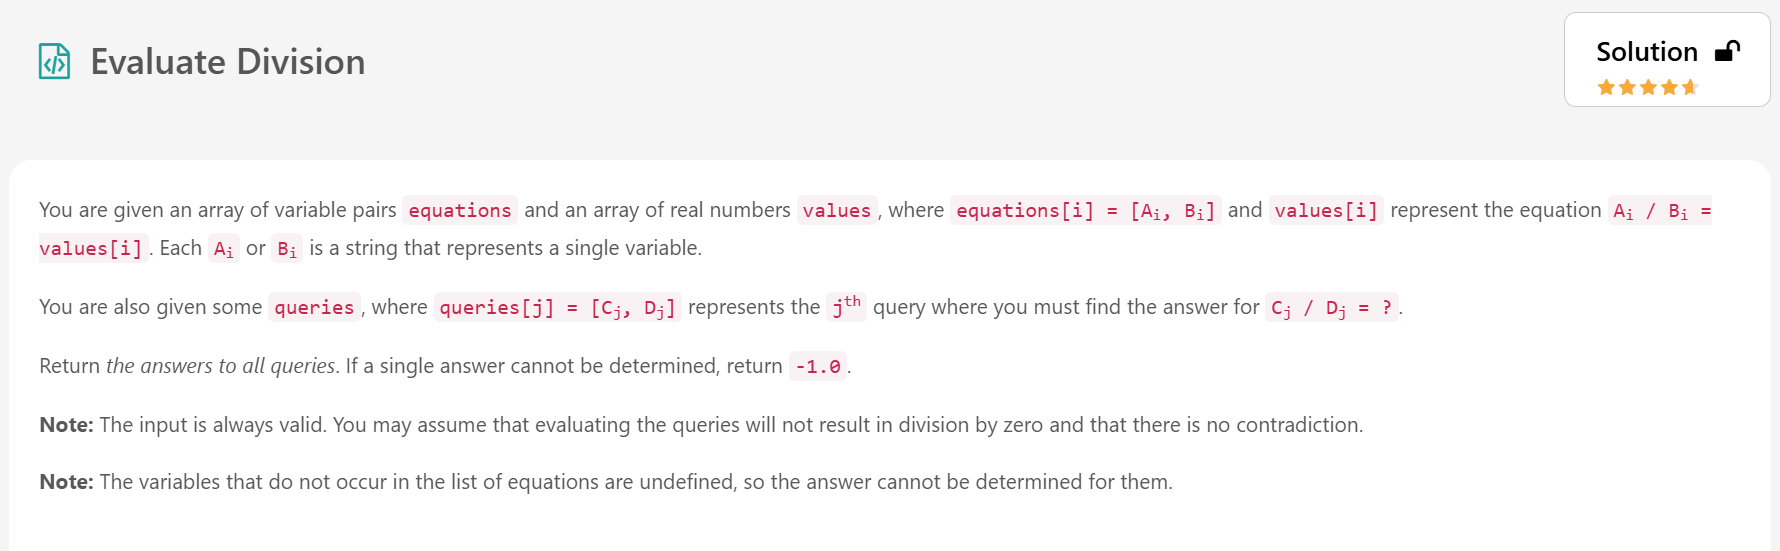

```python
class Solution:
    def calcEquation(self, equations: List[List[str]], values: List[float], queries: List[List[str]]) -> List[float]:
        graph = defaultdict(list)
        
        for i, (a,b) in enumerate(equations):
            graph[a].append((b,values[i]))
            graph[b].append((a,1/values[i]))
            
        def dfs(cur, target, visited):
            if cur == target:
                return 1.0
            
            visited.add(cur)
            
            for nei, weight in graph[cur]:
                if nei not in visited:
                    result = dfs(nei, target, visited)
                    
                    if result != -1.0:
                        return weight * result
                    
            return -1.0
        
        ans = []
        
        for a, b in queries:
            if a not in graph or b not in graph:
                ans.append(-1.0)
            else:
                ans.append(dfs(a, b, set()))
                
        return ans     
```

## Kruskal's Algorithm
Kruskal's algorithm is a greedy algorithm used to find the minimum spanning tree of a graph. The algorithm works by sorting the edges of the graph in non-decreasing order of their weights and then adding edges to the spanning tree while ensuring that no cycles are formed.
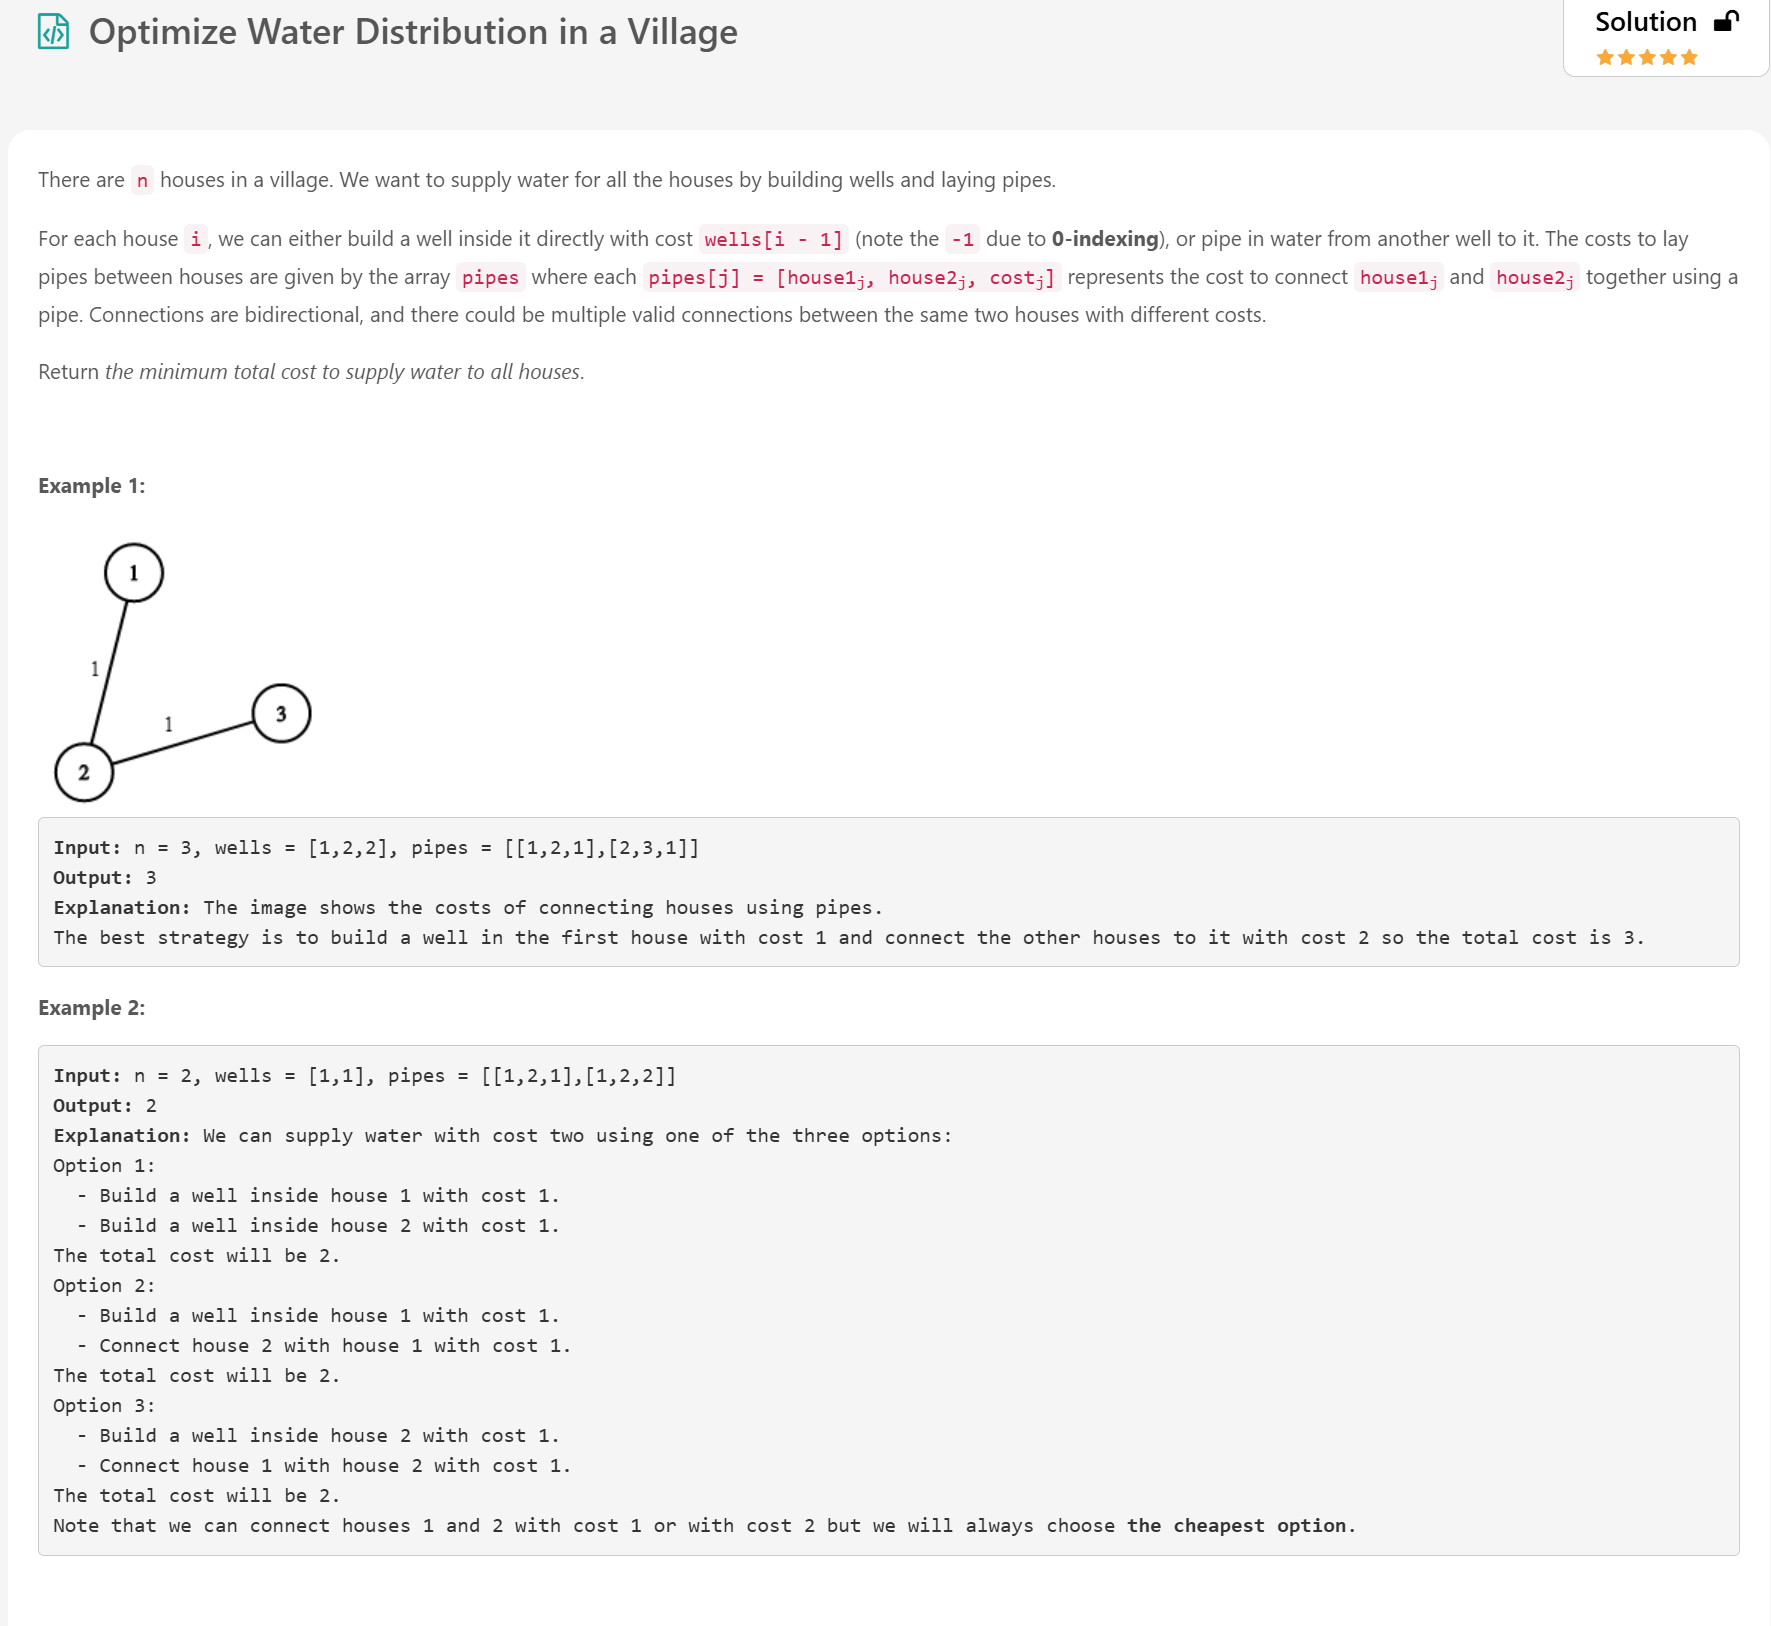
```python
class UnionFind:
    def __init__(self, n):
        self.root = list(range(n))
        self.rank = [1] * n

    def find(self, x):
        if x != self.root[x]:
            self.root[x] = self.find(self.root[x])
        return self.root[x]

    def union(self, x, y):
        rootX = self.find(x)
        rootY = self.find(y)

        if rootX == rootY:
            return False

        if self.rank[rootX] > self.rank[rootY]:
            self.root[rootY] = rootX
        elif self.rank[rootX] < self.rank[rootY]:
            self.root[rootX] = rootY
        else:
            self.root[rootY] = rootX
            self.rank[rootX] += 1

        return True
    
class Solution:
    def minCostToSupplyWater(self, n: int, wells: List[int], pipes: List[List[int]]) -> int:
        edges = []

        # Add virtual edges: building a well
        for i in range(1, n + 1):
            edges.append([wells[i - 1], 0, i])

        # Add pipe edges
        for house1, house2, cost in pipes:
            edges.append([cost, house1, house2])

        # Sort all edges by cost
        edges.sort()

        uf = UnionFind(n + 1)

        total_cost = 0

        for cost, house1, house2 in edges:
            if uf.union(house1, house2):
                total_cost += cost

        return total_cost
        
```

# DFS Template
```python
from collections import defaultdict

def dfs_graph(edges, start):
    # 1. 建图：无向图
    graph = defaultdict(list)
    for a, b in edges:
        graph[a].append(b)
        graph[b].append(a)

    visited = set()
    path = []

    def dfs(node):
        visited.add(node)
        path.append(node)

        for nei in graph[node]:
            if nei not in visited:
                dfs(nei)

    dfs(start)
    return path
```

# Spanning Tree and Minimum Spanning Tree
A spanning tree is a connected subgraph in an undirected graph where all vertices are connected with the minimum number of edges. 
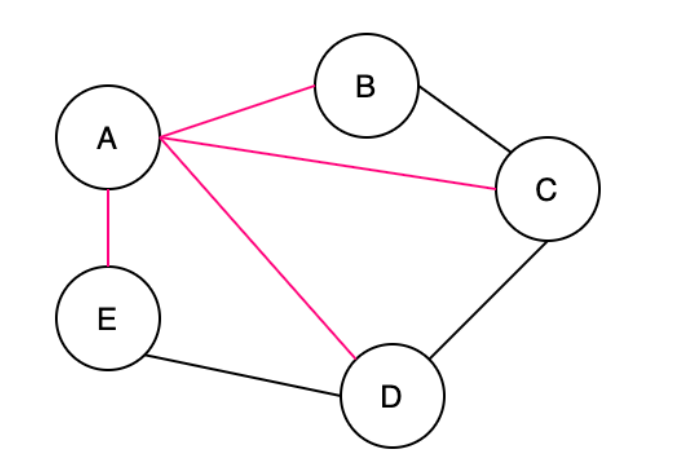

A minimum spanning tree is a spanning tree with the smallest possible total edge weight.
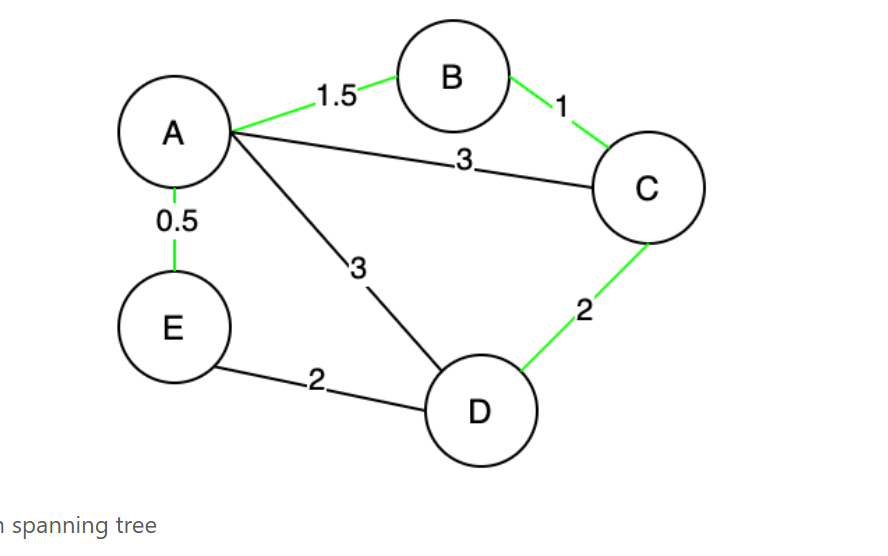

For minimum spanning tree with n nodes:
- The number of edges is n - 1
- no cycles are allowed
- - The total weight is the smallest possible among all spanning trees

## Kruskal's Algorithm
Kruskal's algorithm is a greedy algorithm used to find the minimum spanning tree of a graph. The algorithm works by sorting the edges of the graph in non-decreasing order of their weights and then adding edges to the spanning tree while ensuring that no cycles are formed.

算法适合：
- 题目直接给 edges
- 边比较少
- 需要判断是否会形成环

```python
class UnionFind:
    def __init__(self, n):
        # root[i] 表示节点 i 的父节点
        # 初始时，每个节点的父节点都是自己
        self.root = [i for i in range(n)]

        # rank[i] 表示以 i 为根的树的高度近似值
        # 用来做按秩合并，优化 union 操作
        self.rank = [1] * n

    def find(self, x):
        # 如果 x 是自己的根，直接返回
        if x == self.root[x]:
            return x

        # 路径压缩：
        # 把 x 直接连接到最终根节点上
        self.root[x] = self.find(self.root[x])

        return self.root[x]

    def union(self, x, y):
        # 找到 x 和 y 各自的根节点
        rootX = self.find(x)
        rootY = self.find(y)

        # 如果根节点相同，说明 x 和 y 已经连通
        # 再加入这条边会形成环
        if rootX == rootY:
            return False

        # 按秩合并：
        # 把高度小的树接到高度大的树下面
        if self.rank[rootX] > self.rank[rootY]:
            self.root[rootY] = rootX

        elif self.rank[rootX] < self.rank[rootY]:
            self.root[rootX] = rootY

        else:
            self.root[rootY] = rootX
            self.rank[rootX] += 1

        # 返回 True 表示成功合并，可以加入这条边
        return True


def kruskal(n, edges):
    """
    n: 节点数量，节点编号通常是 0 到 n - 1

    edges: 边列表
    格式为：
        [weight, u, v]

    return:
        MST 的最小总代价
        如果图不连通，返回 -1
    """

    # 第一步：按照边权从小到大排序
    edges.sort()

    # 初始化 Union Find
    uf = UnionFind(n)

    # MST 总权重
    total_cost = 0

    # 已经加入 MST 的边数
    edge_count = 0

    # 第二步：从小到大遍历所有边
    for weight, u, v in edges:

        # 如果 u 和 v 不连通，说明加入这条边不会形成环
        if uf.union(u, v):
            total_cost += weight
            edge_count += 1

            # MST 有 n - 1 条边，达到之后可以提前结束
            if edge_count == n - 1:
                break

    # 如果最后边数不是 n - 1，说明图不连通
    if edge_count != n - 1:
        return -1

    return total_cost
```

## Prim's Algorithm
Prim's algorithm is another greedy algorithm used to find the minimum spanning tree of a graph. The algorithm starts with an arbitrary vertex and grows the spanning tree by repeatedly adding the smallest edge that connects a vertex in the tree to a vertex outside the tree until all vertices are included in the tree.

Prim's algorithm适合：
- 题目给的是图的邻接表
- 图比较稠密
- 从一个点开始扩展更自然

```python
import heapq
from collections import defaultdict


def prim(n, edges):
    """
    n: 节点数量，节点编号通常是 0 到 n - 1

    edges: 边列表
    格式为：
        [u, v, weight]

    return:
        MST 的最小总代价
        如果图不连通，返回 -1
    """

    # 第一步：建立邻接表
    # graph[u] = [(weight, v), ...]
    graph = defaultdict(list)

    for u, v, weight in edges:
        graph[u].append((weight, v))
        graph[v].append((weight, u))

    # visited 记录哪些节点已经加入 MST
    visited = set()

    # 最小堆
    # 堆中的元素格式是：
    # (当前边的权重, 当前节点)
    #
    # 初始从 0 号节点开始，加入 0 号节点的代价是 0
    min_heap = [(0, 0)]

    # MST 总权重
    total_cost = 0

    while min_heap and len(visited) < n:

        # 每次取出当前权重最小的候选边
        cost, node = heapq.heappop(min_heap)

        # 如果这个节点已经加入 MST，说明这是重复候选边，跳过
        if node in visited:
            continue

        # 把当前节点加入 MST
        visited.add(node)

        # 加上连接当前节点的边的代价
        total_cost += cost

        # 把当前节点的邻居加入候选堆
        for nei_cost, nei in graph[node]:

            # 只考虑还没有加入 MST 的节点
            if nei not in visited:
                heapq.heappush(min_heap, (nei_cost, nei))

    # 如果没有访问所有节点，说明图不连通
    if len(visited) != n:
        return -1

    return total_cost
```

# Dijkstra's Algorithm
Dijkstra's algorithm is a popular algorithm used to find the shortest path from a source vertex to all other vertices in a graph with non-negative edge weights. The algorithm works by maintaining a priority queue of vertices based on their current shortest distance from the source vertex and iteratively updating the distances to neighboring vertices until all vertices have been processed.
```python
import heapq
from collections import defaultdict

def dijkstra(n, edges, src):
    """
    n: 节点数量，节点编号 0 到 n - 1
    edges: 边列表，每条边是 [u, v, w]
    src: 起点

    返回:
    dist[i] = 从 src 到 i 的最短距离
    """

    graph = defaultdict(list)

    # 有向图
    for u, v, w in edges:
        graph[u].append((v, w))

    INF = float('inf')
    dist = [INF] * n
    dist[src] = 0

    # heap 里面存: 当前距离, 当前节点
    heap = [(0, src)]

    while heap:
        cur_dist, node = heapq.heappop(heap)

        # 如果当前状态已经不是最优，跳过
        if cur_dist > dist[node]:
            continue

        for nei, weight in graph[node]:
            new_dist = cur_dist + weight

            if new_dist < dist[nei]:
                dist[nei] = new_dist
                heapq.heappush(heap, (new_dist, nei))

    return dist
```

# Bellman-Ford Algorithm
Bellman-Ford algorithm is a dynamic programming algorithm used to find the shortest paths from a single source vertex to all other vertices in a graph, even if the graph contains edges with negative weights. The algorithm works by relaxing the edges repeatedly, allowing it to find the shortest path in O(V * E) time, where V is the number of vertices and E is the number of edges. Bellman-Ford can also detect negative weight cycles in the graph.
```python
class Solution:
    def bellmanFord(self, n, edges, src):
        """
        n: 节点数量，节点编号为 0 到 n - 1
        edges: 边列表，每条边是 [u, v, w]
               表示从 u 到 v，权重为 w
        src: 起点
        """

        INF = float('inf')

        # dist[i] 表示从 src 到 i 的最短距离
        dist = [INF] * n
        dist[src] = 0

        # 最短路径最多经过 n - 1 条边
        for _ in range(n - 1):
            updated = False

            for u, v, w in edges:
                if dist[u] != INF and dist[u] + w < dist[v]:
                    dist[v] = dist[u] + w
                    updated = True

            # 如果这一轮没有任何更新，说明已经收敛，可以提前结束
            if not updated:
                break

        return dist
```

If we restrict the number of edges in the path to at most `max_edges`, we can modify the Bellman-Ford algorithm to run for `max_edges` + 1 iterations instead of `n` - 1 iterations. This way, we only consider paths that use at most `max_edges` edges.

And we need to use `temp` array to store the updated distances in each iteration, to ensure that we are only using the distances from the previous iteration when relaxing edges.

```python
def shortest_path_with_limited_edges(n, edges, src, dst, max_edges):
    """
    n: 节点数量
    edges: 边列表，每条边是 [u, v, w]
    src: 起点
    dst: 终点
    max_edges: 最多允许使用多少条边
    """
    
    INF = float('inf')
    dist = [INF] * n
    dist[src] = 0
    
    for _ in range(max_edges + 1):
        temp = dist[:]
        
        for u, v, w in edges:
            if dist[u] != INF:
                temp[v] = min(temp[v], dist[u] + w)
        
        dist = temp
    
    return dist[dst] if dist[dst] != INF else -1
``` 

# Kahn's Algorithm
Kahn's algorithm is a method for performing topological sorting on a directed acyclic graph (DAG). The algorithm works by repeatedly removing nodes with no incoming edges and adding them to the topological order until all nodes have been processed. If at any point there are no nodes with zero in-degree and there are still nodes left to process, it indicates that the graph contains a cycle and a topological sort is not possible.

```python
from collections import defaultdict, deque
from typing import List

def topological_sort(n: int, edges: List[List[int]]) -> List[int]:
    """
    n: 节点数量，编号 0 到 n - 1
    edges: 有向边列表，例如 [a, b] 表示 a -> b

    return:
        如果存在拓扑排序，返回一个合法顺序
        如果图中有环，返回 []
    """

    graph = defaultdict(list)
    indegree = [0] * n

    # 1. 建图，并统计每个点的入度
    for a, b in edges:
        graph[a].append(b)
        indegree[b] += 1

    # 2. 把所有入度为 0 的点加入队列
    queue = deque()

    for i in range(n):
        if indegree[i] == 0:
            queue.append(i)

    # 3. BFS 处理
    res = []

    while queue:
        node = queue.popleft()
        res.append(node)

        for nei in graph[node]:
            indegree[nei] -= 1

            if indegree[nei] == 0:
                queue.append(nei)

    # 4. 判断是否有环
    if len(res) == n:
        return res
    else:
        return []
```

# Application: Minimum height trees
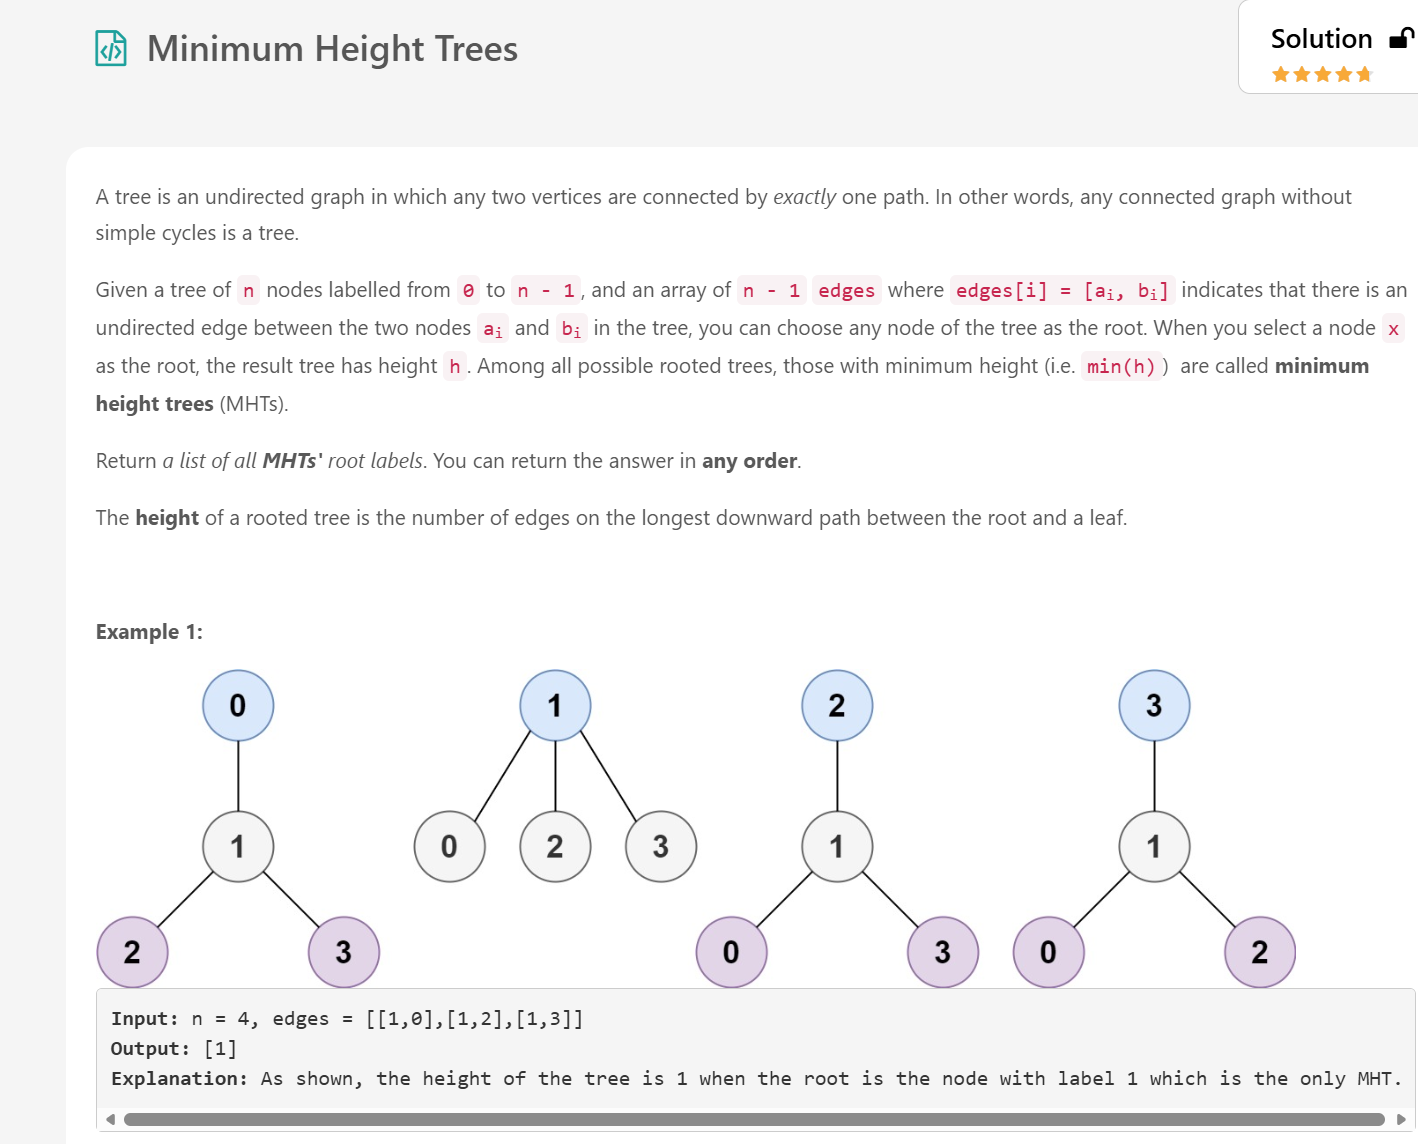

```python
class Solution:
    def findMinHeightTrees(self, n: int, edges: List[List[int]]) -> List[int]:
        if not edges:
            return [0]
        
        graph = defaultdict(list)
        degree = [0] * n
        
        for a, b in edges:
            graph[a].append(b)
            graph[b].append(a)
            degree[a] += 1
            degree[b] += 1
            
        queue = deque()
        
        for i in range(n):
            if degree[i] == 1:
                queue.append(i)
                
        remaining = n
        
        while remaining > 2:
            size = len(queue)
            remaining -= size
            
            for _ in range(size):
                leaf = queue.popleft()
                
                for nei in graph[leaf]:
                    degree[nei] -= 1
                    
                    if degree[nei] == 1:
                        queue.append(nei)
                        
        return list(queue)     
```